In [ ]:
# ============================================================
# Causal Inference & Machine Learning
# Colab Notebook Template
# ============================================================

# uncomment the next line if needed:
# !pip -q install scikit-learn matplotlib seaborn pandas numpy statsmodels

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.linear_model import LinearRegression, Ridge, Lasso, LogisticRegression
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, accuracy_score, roc_auc_score
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.tree import DecisionTreeRegressor
from sklearn.inspection import PartialDependenceDisplay

np.random.seed(42)
sns.set_style("whitegrid")

# Synthetic data for prediction

In [ ]:
# ============================================================
# 1) PREDICTION EXAMPLE
# Goal: learn E[Y|X]
# ============================================================

n = 1000
X1 = np.random.normal(0, 1, n)
X2 = np.random.normal(0, 2, n)
X3 = np.random.normal(0, 3, n)

# Nonlinear data-generating process
Y = 2 * X1 - 1.5 * X2 + 0.5 * X1**2 + np.sin(X3) + np.random.normal(0, 1, n)

df = pd.DataFrame({"X1": X1, "X2": X2, "X3": X3, "Y": Y})
df.head()

,X1,X2,X3,Y
0,0.496714,2.798711,-2.025535,-5.887459
1,-0.138264,1.849267,-0.433556,-4.321357
2,0.647689,0.119261,-2.377260,0.220575
3,1.523030,-1.293874,-0.923885,7.236419
4,-0.234153,1.396447,-5.680844,-1.412436


# Train-test split and baseline models

In [ ]:
# ============================================================
# Train-test split
# ============================================================

X = df[["X1", "X2", "X3"]]
y = df["Y"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# Linear model
lin = LinearRegression()
lin.fit(X_train, y_train)
pred_lin = lin.predict(X_test)
mse_lin = mean_squared_error(y_test, pred_lin)

# Random forest
rf = RandomForestRegressor(n_estimators=300, random_state=42)
rf.fit(X_train, y_train)
pred_rf = rf.predict(X_test)
mse_rf = mean_squared_error(y_test, pred_rf)

print("Linear Regression MSE:", round(mse_lin, 3))
print("Random Forest MSE:", round(mse_rf, 3))

Linear Regression MSE: 2.254
Random Forest MSE: 1.86


# Cross-validation

In [ ]:
# ============================================================
# Cross-validation for model comparison
# ============================================================

cv = KFold(n_splits=5, shuffle=True, random_state=42)

lin_cv = -cross_val_score(
    LinearRegression(), X, y, scoring="neg_mean_squared_error", cv=cv
)

rf_cv = -cross_val_score(
    RandomForestRegressor(n_estimators=300, random_state=42),
    X, y, scoring="neg_mean_squared_error", cv=cv
)

print("Linear CV MSE:", round(lin_cv.mean(), 3), "+/-", round(lin_cv.std(), 3))
print("RF CV MSE:", round(rf_cv.mean(), 3), "+/-", round(rf_cv.std(), 3))

Linear CV MSE: 2.15 +/- 0.266
RF CV MSE: 1.739 +/- 0.244


# Visualize prediction fit

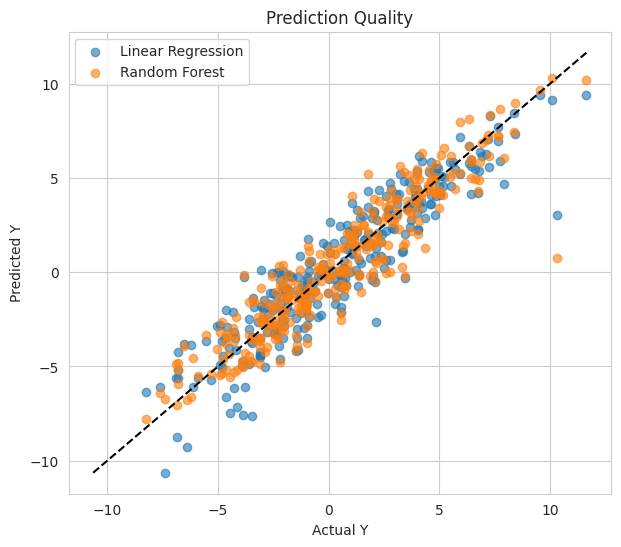

In [ ]:
# ============================================================
# Visualize actual vs predicted
# ============================================================

plt.figure(figsize=(7, 6))
plt.scatter(y_test, pred_lin, alpha=0.6, label="Linear Regression")
plt.scatter(y_test, pred_rf, alpha=0.6, label="Random Forest")
lims = [min(y_test.min(), pred_lin.min(), pred_rf.min()), max(y_test.max(), pred_lin.max(), pred_rf.max())]
plt.plot(lims, lims, "k--")
plt.xlabel("Actual Y")
plt.ylabel("Predicted Y")
plt.title("Prediction Quality")
plt.legend()
plt.show()

# Bias-variance intuition

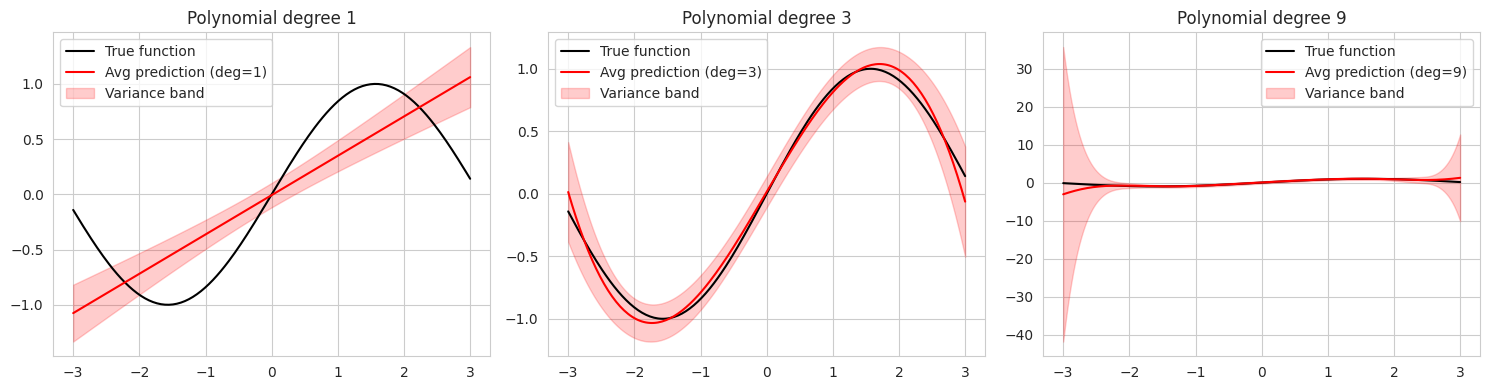

In [ ]:
# ============================================================
# Bias-Variance Illustration with polynomial regression
# ============================================================

x = np.linspace(-3, 3, 200)
true_f = np.sin(x)

noise_levels = [0.1, 0.5, 1.0]
degrees = [1, 3, 9]

plt.figure(figsize=(15, 4))

for i, deg in enumerate(degrees, 1):
    preds = []
    for _ in range(100):
        x_train = np.random.uniform(-3, 3, 30)
        y_train = np.sin(x_train) + np.random.normal(0, 0.5, len(x_train))
        model = Pipeline([
            ("poly", PolynomialFeatures(degree=deg, include_bias=False)),
            ("lin", LinearRegression())
        ])
        model.fit(x_train.reshape(-1, 1), y_train)
        preds.append(model.predict(x.reshape(-1, 1)))
    preds = np.array(preds)

    mean_pred = preds.mean(axis=0)
    plt.subplot(1, 3, i)
    plt.plot(x, true_f, "k", label="True function")
    plt.plot(x, mean_pred, "r", label=f"Avg prediction (deg={deg})")
    plt.fill_between(x, preds.mean(axis=0) - preds.std(axis=0), preds.mean(axis=0) + preds.std(axis=0),
                     color="red", alpha=0.2, label="Variance band")
    plt.title(f"Polynomial degree {deg}")
    plt.legend()

plt.tight_layout()
plt.show()

# Regularization, LASSO, and Ridge

In [ ]:
# ============================================================
# Regularization on high-dimensional data
# ============================================================

n, p = 200, 30
X = np.random.normal(size=(n, p))
true_beta = np.zeros(p)
true_beta[:5] = [3, -2, 1.5, 0, 2]
y = X @ true_beta + np.random.normal(0, 1, n)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

ridge = Pipeline([
    ("scaler", StandardScaler()),
    ("model", Ridge(alpha=10))
])

lasso = Pipeline([
    ("scaler", StandardScaler()),
    ("model", Lasso(alpha=0.1, max_iter=10000))
])

ols = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LinearRegression())
])

models = {"OLS": ols, "Ridge": ridge, "LASSO": lasso}

for name, model in models.items():
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    mse = mean_squared_error(y_test, pred)
    print(f"{name} test MSE: {mse:.3f}")

OLS test MSE: 1.258
Ridge test MSE: 1.439
LASSO test MSE: 0.992


# Compare coefficients

In [ ]:
# ============================================================
# Coefficient comparison
# ============================================================

coef_df = pd.DataFrame({
    "True beta": true_beta,
    "OLS": ols.named_steps["model"].coef_,
    "Ridge": ridge.named_steps["model"].coef_,
    "LASSO": lasso.named_steps["model"].coef_
}, index=[f"X{i+1}" for i in range(p)])

coef_df.head(10)

,True beta,OLS,Ridge,LASSO
X1,3.0,3.361875,3.019185,3.260197
X2,-2.0,-1.980040,-1.715723,-1.816010
X3,1.5,1.302326,1.167309,1.236012
X4,0.0,0.187372,0.167420,0.032300
X5,2.0,2.289271,2.065188,2.185141
X6,0.0,0.109709,0.096677,0.000000
X7,0.0,-0.030254,-0.012440,-0.000000
X8,0.0,0.172142,0.193253,0.097245
X9,0.0,-0.152553,-0.147980,-0.000000
X10,0.0,-0.023818,-0.006372,0.000000


# Plot coefficient shrinkage

<Figure size 1200x500 with 0 Axes>

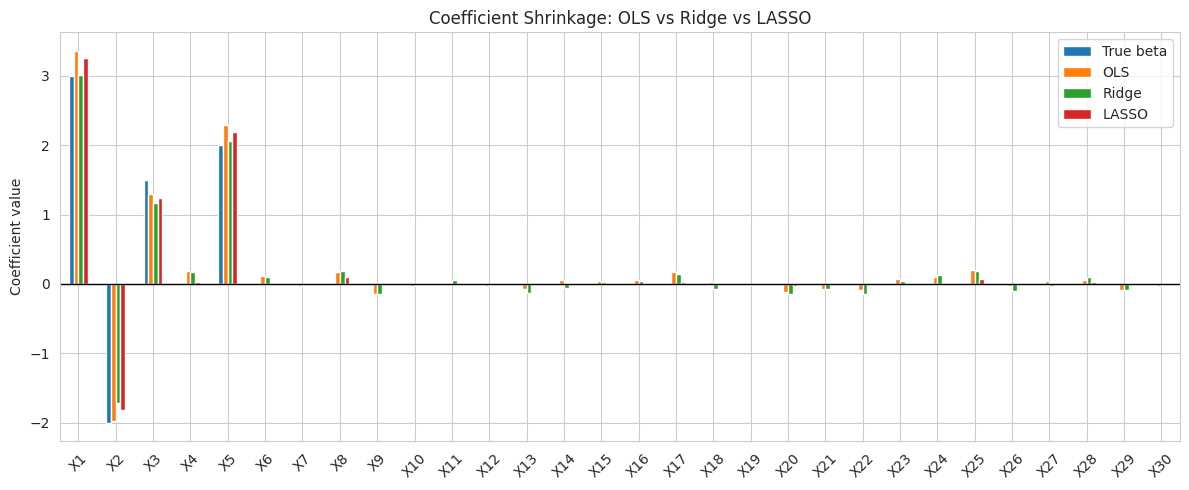

In [ ]:
plt.figure(figsize=(12, 5))
coef_df.plot(kind="bar", figsize=(12, 5))
plt.axhline(0, color="black", linewidth=1)
plt.title("Coefficient Shrinkage: OLS vs Ridge vs LASSO")
plt.ylabel("Coefficient value")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Prediction vs estimation message

Prediction targets the best fit for Y given X.

Causal estimation targets the effect of a treatment on Y.

A model can predict well while giving biased coefficients.

# Simple causality example with confounding

In [ ]:
# ============================================================
# CAUSAL INFERENCE EXAMPLE
# Treatment T affects outcome Y, but confounder Z affects both
# ============================================================

n = 2000
Z = np.random.normal(0, 1, n)                # confounder
T = (0.8 * Z + np.random.normal(0, 1, n) > 0).astype(int)   # treatment depends on Z
Y = 2.0 * T + 1.5 * Z + np.random.normal(0, 1, n)            # outcome depends on T and Z

causal_df = pd.DataFrame({"Z": Z, "T": T, "Y": Y})
causal_df.head()

,Z,T,Y
0,-0.355509,0,0.831935
1,-0.989719,1,0.494425
2,0.682928,0,0.431377
3,1.665966,1,2.850274
4,0.905768,1,2.787187


# Naive vs adjusted estimate

In [ ]:
# ============================================================
# Naive causal estimate
# ============================================================

naive_model = LinearRegression().fit(causal_df[["T"]], causal_df["Y"])
naive_effect = naive_model.coef_[0]

# Adjusted estimate
adj_model = LinearRegression().fit(causal_df[["T", "Z"]], causal_df["Y"])
adj_effect = adj_model.coef_[0]

print("True treatment effect: 2.0")
print("Naive estimate:", round(naive_effect, 3))
print("Adjusted estimate:", round(adj_effect, 3))

True treatment effect: 2.0
Naive estimate: 3.529
Adjusted estimate: 2.04


# Visualize confounding bias

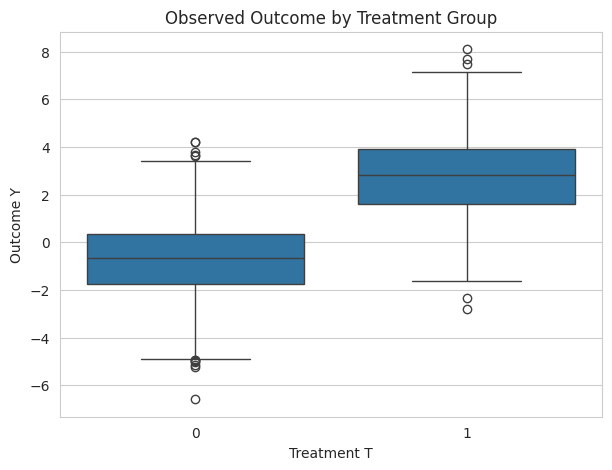

In [ ]:
plt.figure(figsize=(7, 5))
sns.boxplot(data=causal_df, x="T", y="Y")
plt.title("Observed Outcome by Treatment Group")
plt.xlabel("Treatment T")
plt.ylabel("Outcome Y")
plt.show()

# Double ML intuition with residualization

In [ ]:
# ============================================================
# Double ML-style residualization
# Step 1: predict T from controls
# Step 2: predict Y from controls
# Step 3: regress residualized Y on residualized T
# ============================================================

X_controls = causal_df[["Z"]].values
T_vec = causal_df["T"].values
Y_vec = causal_df["Y"].values

m_t = RandomForestRegressor(n_estimators=200, random_state=42)
m_y = RandomForestRegressor(n_estimators=200, random_state=42)

m_t.fit(X_controls, T_vec)
m_y.fit(X_controls, Y_vec)

T_res = T_vec - m_t.predict(X_controls)
Y_res = Y_vec - m_y.predict(X_controls)

dml_model = LinearRegression().fit(T_res.reshape(-1, 1), Y_res)
dml_effect = dml_model.coef_[0]

print("DML-style estimate:", round(dml_effect, 3))

DML-style estimate: 2.027


# Heterogeneous treatment effects

In [ ]:
# ============================================================
# CATE-style simulation: treatment effect varies with X
# tau(X) = 1 + X
# ============================================================

n = 3000
X = np.random.uniform(-2, 2, n)
propensity = 1 / (1 + np.exp(-X))
T = (np.random.uniform(0, 1, n) < propensity).astype(int)

tau = 1 + X
Y0 = 2 * X + np.random.normal(0, 1, n)
Y1 = Y0 + tau
Y = np.where(T == 1, Y1, Y0)

cate_df = pd.DataFrame({"X": X, "T": T, "Y": Y, "tau_true": tau})
cate_df.head()

,X,T,Y,tau_true
0,-1.382941,1,-2.899089,-0.382941
1,-1.532092,0,-3.057497,-0.532092
2,1.444342,1,4.931998,2.444342
3,0.617741,1,2.059490,1.617741
4,1.813783,1,4.373361,2.813783


# Estimate CATE by grouping

/tmp/ipykernel_6471/2233640675.py:6: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  group_est = cate_df.groupby("bin", observed=False).apply(


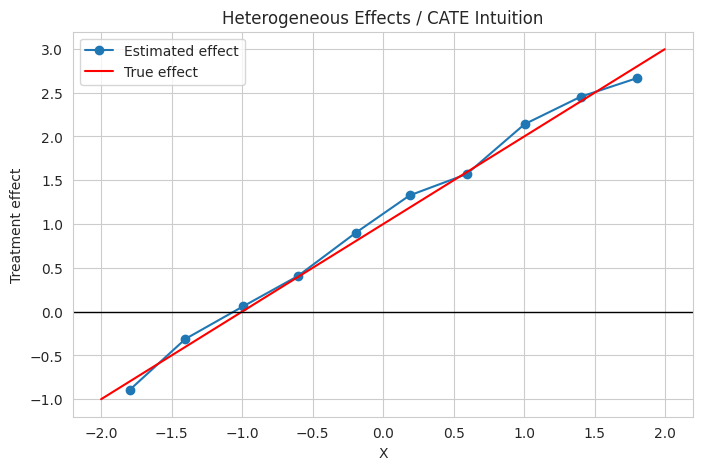

In [ ]:
# ============================================================
# Simple grouped treatment-effect estimate
# ============================================================

cate_df["bin"] = pd.cut(cate_df["X"], bins=10)
group_est = cate_df.groupby("bin", observed=False).apply(
    lambda d: d.loc[d["T"] == 1, "Y"].mean() - d.loc[d["T"] == 0, "Y"].mean()
).reset_index(name="ATE_hat")

group_mid = cate_df.groupby("bin", observed=False)["X"].mean().reset_index(name="X_mid")
cate_plot_df = group_mid.merge(group_est, on="bin")

plt.figure(figsize=(8, 5))
plt.plot(cate_plot_df["X_mid"], cate_plot_df["ATE_hat"], marker="o", label="Estimated effect")
plt.plot(np.sort(X), 1 + np.sort(X), color="red", label="True effect")
plt.axhline(0, color="black", linewidth=1)
plt.xlabel("X")
plt.ylabel("Treatment effect")
plt.title("Heterogeneous Effects / CATE Intuition")
plt.legend()
plt.show()

# Policy learning idea

In [ ]:
# ============================================================
# Policy learning
# Treat if estimated treatment effect > 0
# ============================================================

cate_df["treat_rule"] = (cate_df["tau_true"] > 0).astype(int)

print("Share treated by optimal rule:", cate_df["treat_rule"].mean().round(3))
print("This is the idea behind policy learning: choose actions using predicted effects.")

Share treated by optimal rule: 0.753
This is the idea behind policy learning: choose actions using predicted effects.


# Classification example

In [ ]:
# ============================================================
# Classification example
# ============================================================

n = 1000
X1 = np.random.normal(size=n)
X2 = np.random.normal(size=n)
logit = 1.2 * X1 - 1.0 * X2
prob = 1 / (1 + np.exp(-logit))
Y = (np.random.uniform(size=n) < prob).astype(int)

clf_df = pd.DataFrame({"X1": X1, "X2": X2, "Y": Y})
X = clf_df[["X1", "X2"]]
y = clf_df["Y"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

clf = LogisticRegression()
clf.fit(X_train, y_train)

pred_prob = clf.predict_proba(X_test)[:, 1]
pred_class = clf.predict(X_test)

print("Accuracy:", round(accuracy_score(y_test, pred_class), 3))
print("AUC:", round(roc_auc_score(y_test, pred_prob), 3))

Accuracy: 0.723
AUC: 0.814
